In [1]:
pip install transformers torch pyarrow

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import time
import datetime
import re
import string
import base64
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler, random_split
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from sklearn.preprocessing import MultiLabelBinarizer
from torch.optim import AdamW
from sklearn.metrics import classification_report, multilabel_confusion_matrix

df = pd.read_parquet("/ssh_attacks (1).parquet")

def decode_base64_payload(payload):
    if not isinstance(payload, str):
      return ""
    if "base64" not in payload.lower():
      return payload
    base64_pattern = r'([A-Za-z0-9+/]{20,}={0,2})'
    matches = re.findall(base64_pattern, payload)

    decoded_strings = []
    for match in matches:
        try:
            decoded = base64.b64decode(match).decode('utf-8', errors='ignore')
            # Filter out non-printable characters
            if all(c in string.printable for c in decoded):
                decoded_strings.append(decoded)
        except Exception as e:
            continue
    # return the original payload but with the decoded b64
    result = payload
    for match, decoded in zip(matches, decoded_strings):
        result = result.replace(match, decoded, 1)
    return result

df['decoded_payload'] = df['full_session'].fillna("").astype(str)

df["decoded_payload"] = df["decoded_payload"].apply(decode_base64_payload)

mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df["Set_Fingerprint"])

'''
dato che ogni sessione ha più di un intento contemporaneamente
abbiamo un problema di multi-label classification
quindi ci serve una rappresentazione numerica
per questo con binarizer trasformo ogni insieme in un vettore
di 0 e 1 per capire se un intento c'è nella sessione (1) oppure no (0)
'''

sentences = df["decoded_payload"].tolist()


tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")


'''
per la tokenizzazione prima troviamo la max_len, poi
usiamo la funzione encode come nella guida
'''


print(torch.cuda.is_available())


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

True


In [3]:

'''max_len = 0

for sent in sentences:
  input_ids = tokenizer.encode(sent, add_special_tokens = True,max_length=256,truncation=True)
  MAX_LEN = max(max_len, len(input_ids))


print("Max sentence length found:", MAX_LEN)
'''
MAX_LEN = 128

In [4]:
'''
tokenizzazione completa
'''

input_ids = []
attention_masks = []

for sent in sentences:
    encoded_dict = tokenizer.encode_plus(
        sent,
        add_special_tokens=True,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt"
    )

    input_ids.append(encoded_dict["input_ids"])
    attention_masks.append(encoded_dict["attention_mask"])


#conversione in tensori
input_ids = torch.cat(input_ids, dim=0)
attention_masks = torch.cat(attention_masks, dim=0)
labels = torch.tensor(y, dtype=torch.float)

print("Esempio tokenizzato:")
print("Testo originale:", sentences[0][:200], "...")
print("Token IDs:", input_ids[0])
print("Attention mask:", attention_masks[0])


#training e validation split
dataset = TensorDataset(input_ids, attention_masks, labels)

train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"{train_size:,} training samples")
print(f"{val_size:,} validation samples")

#dataloader

batch_size = 32

train_dataloader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=batch_size
)

validation_dataloader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=batch_size
)



Esempio tokenizzato:
Testo originale: enable ; system ; shell ; sh ; cat /proc/mounts ; /bin/busybox SAEMW ; cd /dev/shm ; cat .s || cp /bin/echo .s ; /bin/busybox SAEMW ; tftp ; wget ; /bin/busybox SAEMW ; dd bs=52 count=1 if=.s || cat . ...
Token IDs: tensor([  101,  9585,  1025,  2291,  1025,  5806,  1025, 14021,  1025,  4937,
         1013,  4013,  2278,  1013, 19363,  1025,  1013,  8026,  1013,  5697,
         8758,  7842,  6633,  2860,  1025,  3729,  1013, 16475,  1013, 14021,
         2213,  1025,  4937,  1012,  1055,  1064,  1064, 18133,  1013,  8026,
         1013,  9052,  1012,  1055,  1025,  1013,  8026,  1013,  5697,  8758,
         7842,  6633,  2860,  1025,  1056,  6199,  2361,  1025,  1059, 18150,
         1025,  1013,  8026,  1013,  5697,  8758,  7842,  6633,  2860,  1025,
        20315, 18667,  1027,  4720,  4175,  1027,  1015,  2065,  1027,  1012,
         1055,  1064,  1064,  4937,  1012,  1055,  1064,  1064,  2096,  3191,
         1045,  1025,  2079,  9052,  1002,  

In [5]:
'''
per il nostro problema non si può usare BertForSequenceClassification
perchè usa CrossEntropyLoss, che non funziona per multi-label
per questo useremo BertModel + nn.Linear che è utile per multi-label
'''

bert = BertModel.from_pretrained(
   "bert-base-uncased",
    output_attentions=False,
    output_hidden_states=False
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert.to(device)

for param in bert.parameters():
    param.requires_grad = False

##DOMANDA 1 ---> AGGIUNTA DI UN LAYER LINEARE FINALE
num_labels = y.shape[1]

#layer finale
classifier = nn.Linear(bert.config.hidden_size, num_labels).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = AdamW(
    classifier.parameters(),
    lr=2e-5,
    eps=1e-8
)

epochs = 4

total_steps = len(train_dataloader) * epochs

scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=0,
                                            num_training_steps=total_steps)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


======== Epoch 1 / 4 ========
Train Loss: 0.1237
Val Loss: 0.0536
Val Acc: 0.9898
Train time: 0:18:33
Validation time: 0:07:57

======== Epoch 2 / 4 ========
Train Loss: 0.0433
Val Loss: 0.0369
Val Acc: 0.9899
Train time: 0:18:38
Validation time: 0:08:00

======== Epoch 3 / 4 ========
Train Loss: 0.0346
Val Loss: 0.0327
Val Acc: 0.9905
Train time: 0:18:42
Validation time: 0:07:58

======== Epoch 4 / 4 ========
Train Loss: 0.0321
Val Loss: 0.0316
Val Acc: 0.9906
Train time: 0:18:36
Validation time: 0:07:57
Training complete!
Total training took 1:46:21 (h:mm:ss)


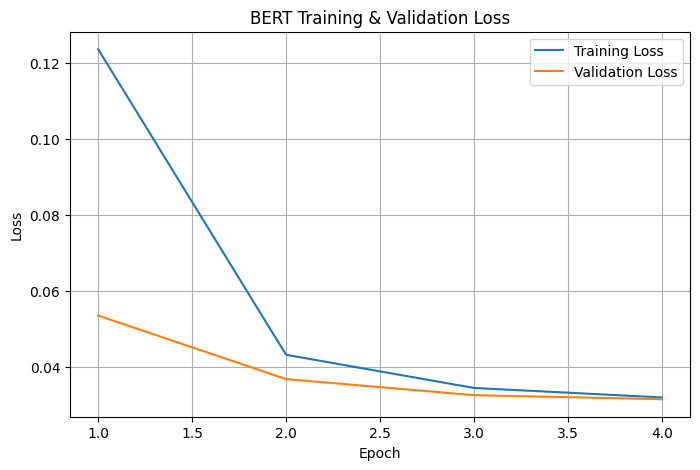

In [6]:
#training loop

#prima funzione per formattare il tempo

def format_time(elapsed):
    elapsed_rounded = int(round(elapsed))
    return str(datetime.timedelta(seconds=elapsed_rounded))

def multilabel_accuracy(y_true, y_pred):
    return (y_true == y_pred).mean()

def evaluate(dataloader):
    bert.eval()
    classifier.eval()

    total_loss = 0
    y_true, y_pred = [], []

    start_time = time.time()

    with torch.no_grad():
        for batch in dataloader:
            ids = batch[0].to(device)
            attn = batch[1].to(device)
            labels = batch[2].to(device)

            outputs = bert(input_ids=ids, attention_mask=attn)
            cls_emb = outputs.last_hidden_state[:, 0, :]
            logits = classifier(cls_emb)

            loss = criterion(logits, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).int()

            y_true.append(labels.cpu().numpy())
            y_pred.append(preds.cpu().numpy())

    elapsed = time.time() - start_time

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    return (
        total_loss / len(dataloader),
        multilabel_accuracy(y_true, y_pred),
        elapsed
    )




training_stats = []
total_t0 = time.time()

for epoch_i in range(epochs):

    print("")
    print(f"======== Epoch {epoch_i+1} / {epochs} ========")

    bert.eval()
    classifier.train()

    t0 = time.time()
    total_train_loss = 0


    for batch in train_dataloader:

        b_input_ids = batch[0].to(device)
        b_attn = batch[1].to(device)
        b_labels = batch[2].to(device)

        optimizer.zero_grad()

        # FORWARD PASS
        outputs = bert(input_ids=b_input_ids, attention_mask=b_attn)
        cls_emb = outputs.last_hidden_state[:, 0, :]
        logits = classifier(cls_emb)

        # CALCOLO LOSS
        loss = criterion(logits, b_labels)
        total_train_loss += loss.item()

        # BACKWARD PASS
        loss.backward()
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    training_time = time.time() - t0

    val_loss, val_acc, val_time = evaluate(validation_dataloader)

    training_stats.append({
        "epoch": epoch_i + 1,
        "Training Loss": avg_train_loss,
        "Valid. Loss": val_loss,
        "Valid. Acc.": val_acc,
        "Training Time": training_time,
        "Validation Time": val_time
    })

    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Acc: {val_acc:.4f}")
    print(f"Train time: {format_time(training_time)}")
    print(f"Validation time: {format_time(val_time)}")

print("Training complete!")
print("Total training took {:} (h:mm:ss)".format(format_time(time.time()-total_t0)))


#creo il dataframe e plot delle learning curves

pd.set_option('display.precision', 2)

df_stats = pd.DataFrame(training_stats)
df_stats = df_stats.set_index('epoch')

df_stats

plt.figure(figsize=(8,5))
plt.plot(df_stats.index, df_stats["Training Loss"], label="Training Loss")
plt.plot(df_stats.index, df_stats["Valid. Loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()





In [7]:
print(df_stats)
'''Classification Report'''
def bert_predict(dataloader):
    y_true, y_pred = [], []

    bert.eval()
    classifier.eval()

    with torch.no_grad():
        for batch in dataloader:
            ids = batch[0].to(device)
            attn = batch[1].to(device)
            labels = batch[2].cpu().numpy()

            outputs = bert(input_ids=ids, attention_mask=attn)
            cls_emb = outputs.last_hidden_state[:, 0, :]
            logits = classifier(cls_emb)

            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.5).astype(int)

            y_true.append(labels)
            y_pred.append(preds)

    return np.vstack(y_true), np.vstack(y_pred)


y_train_true, y_train_pred = bert_predict(train_dataloader)
y_test_true, y_test_pred = bert_predict(validation_dataloader)

print("Classification Report TRAIN (BERT):\n")
print(classification_report(
    y_train_true,
    y_train_pred,
    target_names=mlb.classes_,
    zero_division=0
))

print("----------------------------------")

print("Classification Report TEST (BERT):\n")
print(classification_report(
    y_test_true,
    y_test_pred,
    target_names=mlb.classes_,
    zero_division=0
))

       Training Loss  Valid. Loss  Valid. Acc.  Training Time  Validation Time
epoch                                                                         
1               0.12         0.05         0.99        1113.26           476.69
2               0.04         0.04         0.99        1118.18           480.25
3               0.03         0.03         0.99        1121.77           477.50
4               0.03         0.03         0.99        1116.18           477.21
Classification Report TRAIN (BERT):

                 precision    recall  f1-score   support

Defense Evasion       0.98      0.92      0.95     13388
      Discovery       1.00      1.00      1.00    162505
      Execution       0.96      0.97      0.97     65011
       Harmless       0.00      0.00      0.00      1558
         Impact       0.00      0.00      0.00        21
          Other       0.00      0.00      0.00       234
    Persistence       0.98      1.00      0.99    147796

      micro avg       0.98     

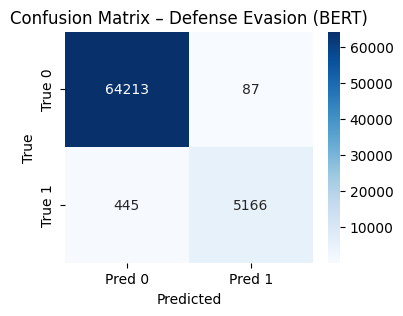

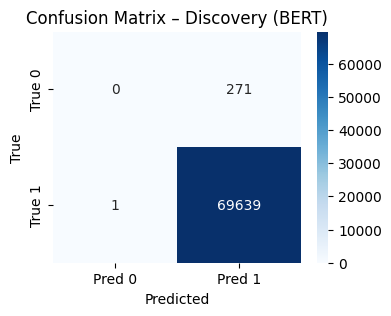

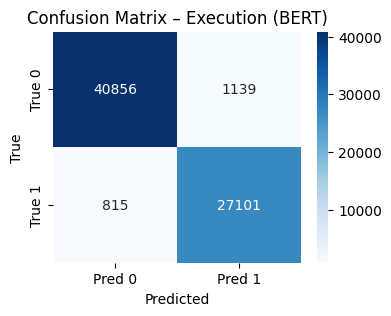

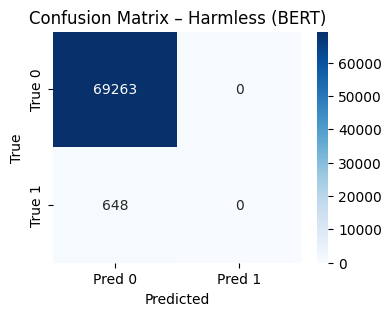

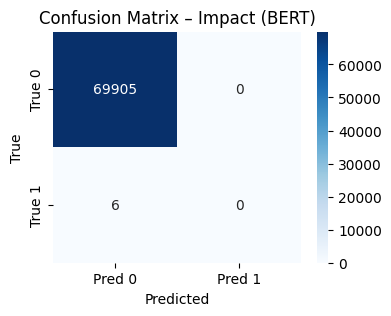

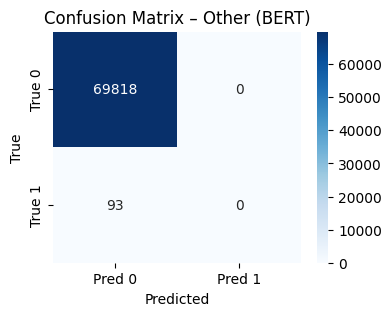

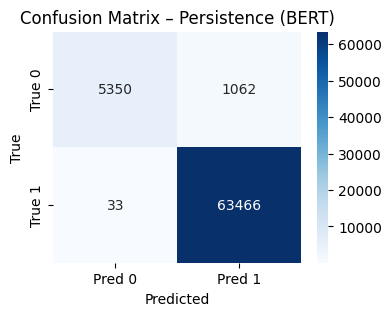

In [8]:
'''Confusion Matrix'''

cms = multilabel_confusion_matrix(y_test_true, y_test_pred)

for i, label in enumerate(mlb.classes_):
    plt.figure(figsize=(4, 3))
    sns.heatmap(
        cms[i],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(f"Confusion Matrix – {label} (BERT)")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()